Deep Learning Models: A collection of various deep learning architectures, models, & their implementations (`PyTorch` or `TensorFlow`) in Jupyter Notebooks.
* Author: _Chizoba Obasi_
* Github Repo: https://github.com/chizkidd/deep-learning-models

In [1]:
%%capture
!pip install watermark
!pip install torchinfo datasets

In [2]:
%load_ext watermark
# %reload_ext watermark
%watermark -a 'Chizoba Obasi' -v -p torch

Author: Chizoba Obasi

Python implementation: CPython
Python version       : 3.12.12
IPython version      : 7.34.0

torch: 2.9.0+cu126



---
# Stacked Gated Recurrent Unit (Stacked GRU) Classifier

The network in this notebook is an implementation of a **Stacked Gated Recurrent Unit (Stacked GRU)** network **[1, 2]**. While a standard GRU is excellent for capturing temporal dependencies, a **Stacked GRU** introduces a hierarchical dimension. By stacking multiple layers, the model can learn different levels of abstraction: the lower layers capture local syntactic patterns (grammar and spelling), while the higher layers represent more complex, semantic concepts (context and intent).

<br><br>

**Network Architecture:**

In a Stacked GRU, the hidden state output of the first layer serves as the input sequence for the second layer. This "deep" recurrent structure allows the network to build a multi-layered representation of the text. This is particularly effective for complex datasets like **AG News**, where the relationship between words is not just sequential but hierarchical.


<br><br>

---

### **Key Concepts of the `Stacked GRU` Architecture:**

1. **Hierarchical Abstraction:** Much like a CNN has lower layers for edges and higher layers for shapes, a Stacked GRU uses Layer 1 to understand "how words are built" and Layer 2+ to understand "what the sentence means."
2. **Hidden State Propagation:** For each time step $t$, the output of the first layer $h_t^{(1)}$ is passed as the input $x_t^{(2)}$ to the second layer.
3. **Increased Capacity:** Stacking allows the model to learn more complex functions without necessarily increasing the `hidden_size` to an unmanageable degree, keeping the feature vector "dense."


<br><br>

---

### **Quick Comparison Table: Standard GRU vs. Stacked GRU**

| Feature | Standard GRU (Single Layer) | Stacked GRU (Multi-Layer) |
| --- | --- | --- |
| **Depth** | 1 Recurrent Layer | **2+ Recurrent Layers** |
| **Data Flow** | Input $\rightarrow$ Hidden $\rightarrow$ Output | **Input $\rightarrow$ Layer 1 $\rightarrow$ Layer 2 $\rightarrow$ Output** |
| **Abstraction** | Linear/Temporal | **Hierarchical/Deep** |
| **Parameter Count** | Base | **$N \times$ Base (Where $N$ is layers)** |
| **Risk** | Lower | **Higher (Potential Vanishing Gradients)** |
| **Best For** | Simple sequences / Small data | **Complex semantics / Large datasets** |

<br><br>

---

**REFERENCES:**

1. Pascanu, Razvan, et al. ["How to construct deep recurrent neural networks."](https://arxiv.org/abs/1312.6026) *arXiv preprint arXiv:1312.6026*, 2013. **(The "Deep RNN" Foundation)**
2. Cho, Kyunghyun, et al. ["Learning Phrase Representations using RNN Encoder-Decoder for Statistical Machine Translation."](https://arxiv.org/abs/1406.1078) *arXiv preprint arXiv:1406.1078*, 2014. **(Original GRU Paper)**
3. Zhang, Xiang, Junbo Zhao, and Yann LeCun. ["Character-level Convolutional Networks for Text Classification."](https://arxiv.org/abs/1509.01626) *NeurIPS*, 2015.
4. Maas, Andrew L., et al. ["Learning Word Vectors for Sentiment Analysis."](https://ai.stanford.edu/~amaas/papers/wvSent_acl2011.pdf) *ACL*, 2011. **(IMDB Dataset Source)**
5. Google. (2026). ["Gemini 3 Flash"](https://gemini.google.com/) [Large language model]. Google AI

---


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence
from datasets import load_dataset, DatasetDict
from collections import Counter

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report


# from torch.cuda.amp import GradScaler, autocast
from torch.amp import GradScaler, autocast
from torchinfo import summary

import seaborn as sns
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
%matplotlib inline

import pandas as pd
import numpy as np
import math
import time
import os
import random
import re

if torch.cuda.is_available():
    torch.backends.cudnn.deterministic = True

In [4]:
def set_all_seeds(seed):
    os.environ["PL_GLOBAL_SEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

---
# 0. Model Hyperparameters
---

In [5]:
##########################
### SETTINGS
##########################

# Hyperparameters
RANDOM_SEED = 123
BATCH_SIZE = 128
LEARNING_RATE = 0.0005    # 0.001
NUM_EPOCHS = 10          # News topics usually converge faster than char-level text
# NUM_CLASSES = 4        # [World, Sports, Business, Sci/Tech]

# Vocabulary & Architecture
VOCABULARY_SIZE = 20000 
EMBEDDING_DIM = 128
HIDDEN_DIM = 128 #256
DROPOUT_P = 0.5        # Crucial for Stacked architectures to prevent overfitting

# Sequence Constraints
# MAX_LEN = 100          # AG News sentences are shorter than Wikipedia/Shakespeare chunks
# Set device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(DEVICE)

cuda


---
# 1. Data Preparation & Loading

---

In [6]:
# 1. Load Dataset 
DATASET_CONFIG = "ag_news"  # Use "imdb", "ag_news", "amazon_reviews_multi", etc.
raw_datasets = load_dataset(DATASET_CONFIG)


# 2. Split 10% of 'train' to create a 'validation' set (seed for reproducibility)
train_val_split = raw_datasets["train"].train_test_split(test_size=0.1, seed=RANDOM_SEED)

ds_splits = DatasetDict({
    'train': train_val_split['train'],
    'validation': train_val_split['test'], # The 10% we just carved out
    'test': raw_datasets['test']
})

print(ds_splits)

# ------------Robust Extraction of Class Names----------
dataset_label_features = raw_datasets['train'].features['label']

if hasattr(dataset_label_features, 'names'):
    class_names = dataset_label_features.names
    NUM_CLASSES = len(class_names)
else:
    # Fallback for datasets that don't have metadata names
    NUM_CLASSES = len(set(raw_datasets['train']['label']))
    class_names = [f"Class {i}" for i in range(NUM_CLASSES)]

# ----------Auto-detect Binary vs Multi-class-------------
# Note: For IMDB, NUM_CLASSES is 2. For AG News, it's 4.
# IS_BINARY = True if NUM_CLASSES <= 2 else False

is_imdb = DATASET_CONFIG.lower() == "imdb"
IS_BINARY = True if is_imdb else False


# --------DYNAMIC HYPERPARAMETERS ----------------------
# If binary, output layer needs 1 node (for Sigmoid: BCEWithLogitsLoss); else num_classes (for Softmax)
MODEL_OUTPUT_SIZE = 1 if IS_BINARY else NUM_CLASSES

print(f"\n[ROBUST CONFIG COMPLETE]")
print(f"Dataset: {DATASET_CONFIG} | Num of Classes : {NUM_CLASSES} | Classes: {class_names}")
print(f"Is Binary: {IS_BINARY} | Model Output Nodes: {MODEL_OUTPUT_SIZE}")

# 2. Build Vocabulary (From Scratch Logic)
tokenizer = lambda text: re.findall(r'\w+', text.lower())
word_counts = Counter()

# Important: We only iterate over ds_splits['train']
for text in ds_splits['train']['text']:
    word_counts.update(tokenizer(text))

# Filter rare words and create mapping: : <PAD>=0, <UNK>=1, then top 20k words
vocab = {word: i + 2 for i, (word, count) in enumerate(word_counts.most_common(VOCABULARY_SIZE))}
vocab['<PAD>'] = 0
vocab['<UNK>'] = 1

print(f"Vocab size: {len(vocab)}")
VOCAB_SIZE = len(vocab)

# 3. Custom Dataset Class
class TextDataset(torch.utils.data.Dataset):
    def __init__(self, dataset_split):
        self.data = dataset_split

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # Return raw text and label. Let collate_fn handle the rest.
        item = self.data[idx]
        return item['text'], item['label']

# 4. Robust Text Pipeline
def text_pipeline(text, max_len=128):
    tokens = tokenizer(text)
    # Use .get(t, 1) because 1 is your <UNK> index
    return [vocab.get(t, 1) for t in tokens][:max_len]

# 5. Robust Collate Batch
def collate_batch(batch):
    label_list, text_list, lengths = [], [], []

    for _text, _label in batch:
        # 1. Labels: Use LONG for AG News (Multi-class)
        label_list.append(_label)

        # 2. Numericalize and Truncate
        processed_text = torch.tensor(text_pipeline(_text), dtype=torch.int64)
        text_list.append(processed_text)
        lengths.append(processed_text.size(0))

    # 3. Padding logic
    # We use <PAD> index 0. We use vocab.get just in case names change.
    pad_idx = vocab.get('<PAD>', 0)

    # This dynamically pads to the longest sequence in THIS batch (more efficient)
    text_list_padded = pad_sequence(text_list, batch_first=True, padding_value=pad_idx)
    label_tensor = torch.tensor(label_list, dtype=torch.long)
    length_tensor = torch.tensor(lengths, dtype=torch.int64)

    return text_list_padded.to(DEVICE), label_tensor.to(DEVICE), length_tensor.to(DEVICE)

# 6. Initialize DataLoaders
train_ds = TextDataset(ds_splits['train'])
val_ds   = TextDataset(ds_splits['validation'])
test_ds  = TextDataset(ds_splits['test'])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_batch)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch)

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 108000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 12000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})

[ROBUST CONFIG COMPLETE]
Dataset: ag_news | Num of Classes : 4 | Classes: ['World', 'Sports', 'Business', 'Sci/Tech']
Is Binary: False | Model Output Nodes: 4
Vocab size: 20002


---
# 2. Model Creation

---


In [7]:
class GRUCellFromScratch(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size

        # We need weights for 3 operations:
        # Update gate (z), Reset gate (r), and Candidate hidden state (h_tilde)
        self.gate_weights = nn.Linear(input_size + hidden_size, 2 * hidden_size)
        self.candidate_weights = nn.Linear(input_size + hidden_size, hidden_size)

    def forward(self, x, h_prev):
        # x: [batch, input_size]
        # h_prev: [batch, hidden_size]

        # 1. Calculate Update (z) and Reset (r) gates
        combined = torch.cat((x, h_prev), dim=1)
        gates = torch.sigmoid(self.gate_weights(combined))
        z_gate, r_gate = gates.chunk(2, dim=1)

        # 2. Calculate Candidate Hidden State (h_tilde)
        # We use the Reset gate to "mask" the previous hidden state
        combined_candidate = torch.cat((x, r_gate * h_prev), dim=1)
        h_tilde = torch.tanh(self.candidate_weights(combined_candidate))

        # 3. Final Hidden State update
        # This is a linear interpolation between past and candidate
        h_curr = (1 - z_gate) * h_prev + z_gate * h_tilde

        return h_curr

In [8]:
class StackedGRUFromScratch(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_size, output_size, dropout_p=0.5):
        super().__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        
        self.gru1 = GRUCellFromScratch(embed_dim, hidden_size)
        self.gru2 = GRUCellFromScratch(hidden_size, hidden_size)
        
        self.dropout = nn.Dropout(dropout_p)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x, lengths):
        batch_size, seq_len = x.shape
        x = self.embedding(x)
        
        h1 = torch.zeros(batch_size, self.hidden_size).to(x.device)
        h2 = torch.zeros(batch_size, self.hidden_size).to(x.device)

        # --- LAYER 1 ---
        l1_all_h = []
        for t in range(seq_len):
            h1_next = self.gru1(x[:, t, :], h1)
            
            # MASK 1: Only update if t < actual length
            mask = (t < lengths).float().unsqueeze(1)
            h1 = (mask * h1_next) + ((1 - mask) * h1)
            
            l1_all_h.append(h1.unsqueeze(1))
        
        l1_all_h = torch.cat(l1_all_h, dim=1)
        
        # --- VERTICAL DROPOUT ---
        l1_all_h = self.dropout(l1_all_h)

        # --- LAYER 2 ---
        l2_all_h = []
        for t in range(seq_len):
            # Input to L2 is the masked/dropped output of L1
            h2_next = self.gru2(l1_all_h[:, t, :], h2)
            
            # MASK 2: Freeze h2 as well once padding starts
            mask = (t < lengths).float().unsqueeze(1)
            h2 = (mask * h2_next) + ((1 - mask) * h2)
            
            l2_all_h.append(h2.unsqueeze(1))
            
        l2_all_h = torch.cat(l2_all_h, dim=1)

        # --- FINAL SELECTION ---
        idx = (lengths - 1).view(-1, 1, 1).expand(batch_size, 1, self.hidden_size)
        last_h = l2_all_h.gather(1, idx).squeeze(1)

        return self.fc(last_h)

In [9]:
def get_robust_maxlen(dataset, tokenizer, p=95, absolute_max=512):
    # 1. Get the statistical length
    lengths = [len(tokenizer(ex[0])) for ex in dataset]
    p_length = np.percentile(lengths, p)

    # 2. Find the next power of 2
    # math.log2 gives the exponent, ceil rounds up, 2** raises it back
    # We use max(16, ...) to ensure we don't get a tiny length like 4 or 8
    robust_len = 2 ** math.ceil(math.log2(max(16, p_length)))

    # 3. Cap at absolute_max
    final_len = min(robust_len, absolute_max)

    print(f"{p}th Percentile: {p_length:.2f}")
    print(f"Nearest Power of 2: {robust_len}")
    print(f"Final Robust MAX_LEN: {final_len}")

    return final_len

# Usage
MAX_LEN = get_robust_maxlen(train_ds, tokenizer, p=95)

95th Percentile: 58.00
Nearest Power of 2: 64
Final Robust MAX_LEN: 64


In [10]:
DATASET_CONFIG, IS_BINARY, MODEL_OUTPUT_SIZE, VOCAB_SIZE, MAX_LEN, 

('ag_news', False, 4, 20002, 64)

In [11]:
set_all_seeds(RANDOM_SEED)

model = StackedGRUFromScratch(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBEDDING_DIM,
    hidden_size=HIDDEN_DIM,
    output_size=MODEL_OUTPUT_SIZE,  
    dropout_p=0.5
).to(DEVICE)

summary(model,
        input_data=(torch.zeros((BATCH_SIZE, MAX_LEN), dtype=torch.long).to(DEVICE),
                    torch.ones((BATCH_SIZE,), dtype=torch.long).to(DEVICE) * MAX_LEN),
        col_names=["input_size", "output_size", "num_params", "mult_adds"],
        device=DEVICE)

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Mult-Adds
StackedGRUFromScratch                    [128, 64]                 [128, 4]                  --                        --
├─Embedding: 1-1                         [128, 64]                 [128, 64, 128]            2,560,256                 327,712,768
├─GRUCellFromScratch: 1-2                [128, 128]                [128, 128]                --                        --
│    └─Linear: 2-1                       [128, 256]                [128, 256]                65,792                    8,421,376
│    └─Linear: 2-2                       [128, 256]                [128, 128]                32,896                    4,210,688
├─GRUCellFromScratch: 1-3                [128, 128]                [128, 128]                (recursive)               --
│    └─Linear: 2-3                       [128, 256]                [128, 256]                (recursive)            

In [12]:
def count_parameters(model):
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    embedding_params = sum(p.numel() for p in model.embedding.parameters())
    gru_params = total_params - embedding_params - sum(p.numel() for p in model.fc.parameters())
    
    print(f"{'Component':<15} | {'Parameters':<12}")
    print("-" * 30)
    print(f"{'Embeddings':<15} | {embedding_params:,}")
    print(f"{'Stacked GRU':<15} | {gru_params:,}")
    print(f"{'Classifier':<15} | {sum(p.numel() for p in model.fc.parameters()):,}")
    print("-" * 30)
    print(f"{'TOTAL':<15} | {total_params:,}")

count_parameters(model)

Component       | Parameters  
------------------------------
Embeddings      | 2,560,256
Stacked GRU     | 197,376
Classifier      | 516
------------------------------
TOTAL           | 2,758,148


---
# 3. Model Training, Testing & Evaluation

---

In [13]:
def evaluate_classification(model, data_loader, device, is_binary=False, class_names=None, plot=False):
    model.eval()
    all_preds = []
    all_labels = []
    total_loss = 0
    
    # Selection of loss function
    criterion = torch.nn.CrossEntropyLoss() if not is_binary else torch.nn.BCEWithLogitsLoss()

    with torch.no_grad():
        for inputs, labels, lengths in data_loader:
            # FIX 1: Move lengths to device for masking logic
            inputs, labels, lengths = inputs.to(device), labels.to(device), lengths.to(device)
            
            logits = model(inputs, lengths)
            
            # FIX 2: Handle shape for Binary Classification
            if is_binary:
                loss = criterion(logits.squeeze(), labels.float())
                preds = (torch.sigmoid(logits.squeeze()) > 0.5).int()
            else:
                loss = criterion(logits, labels.long())
                preds = torch.argmax(logits, dim=1)
            
            # Use inputs.size(0) to weigh the loss correctly by batch size
            total_loss += loss.item() * inputs.size(0)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Calculate metrics
    avg_loss = total_loss / len(data_loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='binary' if is_binary else 'macro')
    
    # Only print and plot if we are doing a final audit, not every epoch
    if plot:
        print(f"Loss: {avg_loss:.4f} | Accuracy: {acc:.2%} | F1: {f1:.4f}")
        print("\nClassification Report:\n", classification_report(all_labels, all_preds, target_names=class_names))
        
        
        
        cm = confusion_matrix(all_labels, all_preds)
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.title('Confusion Matrix')
        plt.show()

    return avg_loss, acc, f1

In [14]:
def train_model(model, train_loader, val_loader, optimizer, criterion, scheduler, num_epochs, device, is_binary=False):
    start_time = time.time()
    history = {
        'train_loss': [], 'val_loss': [], 
        'train_acc': [], 'val_acc': [], 
        'val_f1': [], 'lrs': []
    }

    print(f"Starting training on {device}...")

    for epoch in range(num_epochs):
        # --- 1. TRAINING PHASE ---
        model.train()
        train_running_loss = 0.0
        train_correct = 0
        train_total = 0

        for inputs, labels, lengths in train_loader:
            inputs, labels, lengths = inputs.to(device), labels.to(device), lengths.to(device)

            optimizer.zero_grad()
            logits = model(inputs, lengths)

            if is_binary:
                loss = criterion(logits.squeeze(), labels.float())
                preds = (torch.sigmoid(logits.squeeze()) > 0.5).long()
            else:
                loss = criterion(logits, labels.long())
                preds = torch.argmax(logits, dim=1)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_running_loss += loss.item() * inputs.size(0)
            train_correct += (preds == labels).sum().item()
            train_total += labels.size(0)

        # Epoch Metrics
        epoch_train_loss = train_running_loss / train_total
        epoch_train_acc = (train_correct / train_total) #* 100

        # --- 2. VALIDATION PHASE ---
        epoch_val_loss, epoch_val_acc, epoch_val_f1 = evaluate_classification(
            model, val_loader, device, is_binary=is_binary, plot=False
        )

        # --- 3. UPDATES & LOGGING ---
        scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']

        history['train_loss'].append(epoch_train_loss)
        history['val_loss'].append(epoch_val_loss)
        history['train_acc'].append(epoch_train_acc)
        history['val_acc'].append(epoch_val_acc)
        history['val_f1'].append(epoch_val_f1)
        history['lrs'].append(current_lr)

        print(f'Epoch {epoch + 1}/{num_epochs} | '
              f'Acc (Train/Val): {epoch_train_acc:.2%} / {epoch_val_acc:.2%} | '
              f'F1 (Val): {epoch_val_f1:.4f} | '
              f'Loss (Val): {epoch_val_loss:.4f} | '
              f'LR: {current_lr:.6f}')

    total_time = (time.time() - start_time) / 60
    print(f'\nTotal Training Time: {total_time:.2f} min')
    return history

In [15]:
def plot_history(history):
    epochs = range(1, len(history['train_loss']) + 1)
    
    # Check for all possible metrics
    has_acc = 'val_acc' in history
    has_f1  = 'val_f1' in history  # Added for robustness
    has_gen = 'val_ppl' in history
    
    # Universal plots: Loss + Learning Rate = 2
    num_plots = 2 + int(has_acc) + int(has_f1) + int(has_gen)
    
    plt.figure(figsize=(num_plots * 5, 5))

    # --- Plot 1: Loss ---
    plt.subplot(1, num_plots, 1)
    plt.plot(epochs, history['train_loss'], 'o-', label='Train Loss')
    plt.plot(epochs, history['val_loss'], 's-', label='Val Loss')
    plt.title('Cross Entropy Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plot_idx = 2

    # --- Plot 2: Accuracy (%) ---
    if has_acc:
        plt.subplot(1, num_plots, plot_idx)
        # Using np.array ensures math works on the whole list at once
        plt.plot(epochs, np.array(history['train_acc']) * 100, 'o-', label='Train Acc', color='green')
        plt.plot(epochs, np.array(history['val_acc']) * 100, 's-', label='Val Acc', color='darkgreen')
        plt.title('Accuracy (%)')
        plt.xlabel('Epochs')
        plt.ylabel('Percentage')
        plt.ylim(0, 105) # Robust: Keeps the scale consistent
        plt.legend()
        plt.grid(True, alpha=0.3)
        plot_idx += 1

    # --- Plot 3: F1 Score (%) ---
    if has_f1:
        plt.subplot(1, num_plots, plot_idx)
        # Mapping F1 to percentage scale for consistency
        plt.plot(epochs, np.array(history['val_f1']) * 100, 'd-', label='Val F1', color='teal')
        plt.title('F1 Score (%)')
        plt.xlabel('Epochs')
        plt.ylabel('Percentage')
        plt.ylim(0, 105)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plot_idx += 1

    # --- Plot 4: Generative Metrics ---
    if has_gen:
        plt.subplot(1, num_plots, plot_idx)
        ax1 = plt.gca()
        ax1.plot(epochs, history['val_ppl'], 'o-', label='Perplexity', color='purple')
        ax1.set_ylabel('Perplexity', color='purple')
        if 'val_bpc' in history:
            ax2 = ax1.twinx()
            ax2.plot(epochs, history['val_bpc'], 'x--', label='BPC', color='magenta')
            ax2.set_ylabel('Bits Per Character', color='magenta')
        plt.title('Generative Metrics')
        ax1.set_xlabel('Epochs')
        plot_idx += 1

    # --- Plot 5: Learning Rate (Always Last) ---
    plt.subplot(1, num_plots, num_plots)
    plt.plot(epochs, history['lrs'], label='LR', color='orange', linewidth=2)
    plt.title('Learning Rate Schedule')
    plt.xlabel('Epochs')
    plt.ylabel('Rate')
    plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [16]:
DATASET_CONFIG, IS_BINARY, MODEL_OUTPUT_SIZE, VOCAB_SIZE, MAX_LEN, 

('ag_news', False, 4, 20002, 64)

In [17]:
# 1. Setup
criterion = nn.BCEWithLogitsLoss() if IS_BINARY else nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

# 2. Train
history = train_model(
    model, train_loader, val_loader, 
    optimizer, criterion, scheduler, 
    NUM_EPOCHS, DEVICE, is_binary=IS_BINARY
)

Starting training on cuda...
Epoch 1/10 | Acc (Train/Val): 72.53% / 83.69% | F1 (Val): 0.8360 | Loss (Val): 0.4569 | LR: 0.000488
Epoch 2/10 | Acc (Train/Val): 85.71% / 85.38% | F1 (Val): 0.8529 | Loss (Val): 0.4099 | LR: 0.000452
Epoch 3/10 | Acc (Train/Val): 87.29% / 86.71% | F1 (Val): 0.8671 | Loss (Val): 0.3824 | LR: 0.000397
Epoch 4/10 | Acc (Train/Val): 87.94% / 86.59% | F1 (Val): 0.8648 | Loss (Val): 0.3813 | LR: 0.000327
Epoch 5/10 | Acc (Train/Val): 88.55% / 87.08% | F1 (Val): 0.8697 | Loss (Val): 0.3710 | LR: 0.000250
Epoch 6/10 | Acc (Train/Val): 89.19% / 87.92% | F1 (Val): 0.8788 | Loss (Val): 0.3486 | LR: 0.000173
Epoch 7/10 | Acc (Train/Val): 90.19% / 88.93% | F1 (Val): 0.8886 | Loss (Val): 0.3247 | LR: 0.000103
Epoch 8/10 | Acc (Train/Val): 91.24% / 89.49% | F1 (Val): 0.8947 | Loss (Val): 0.3088 | LR: 0.000048
Epoch 9/10 | Acc (Train/Val): 92.10% / 89.67% | F1 (Val): 0.8961 | Loss (Val): 0.3048 | LR: 0.000012
Epoch 10/10 | Acc (Train/Val): 92.67% / 89.96% | F1 (Val): 0.8

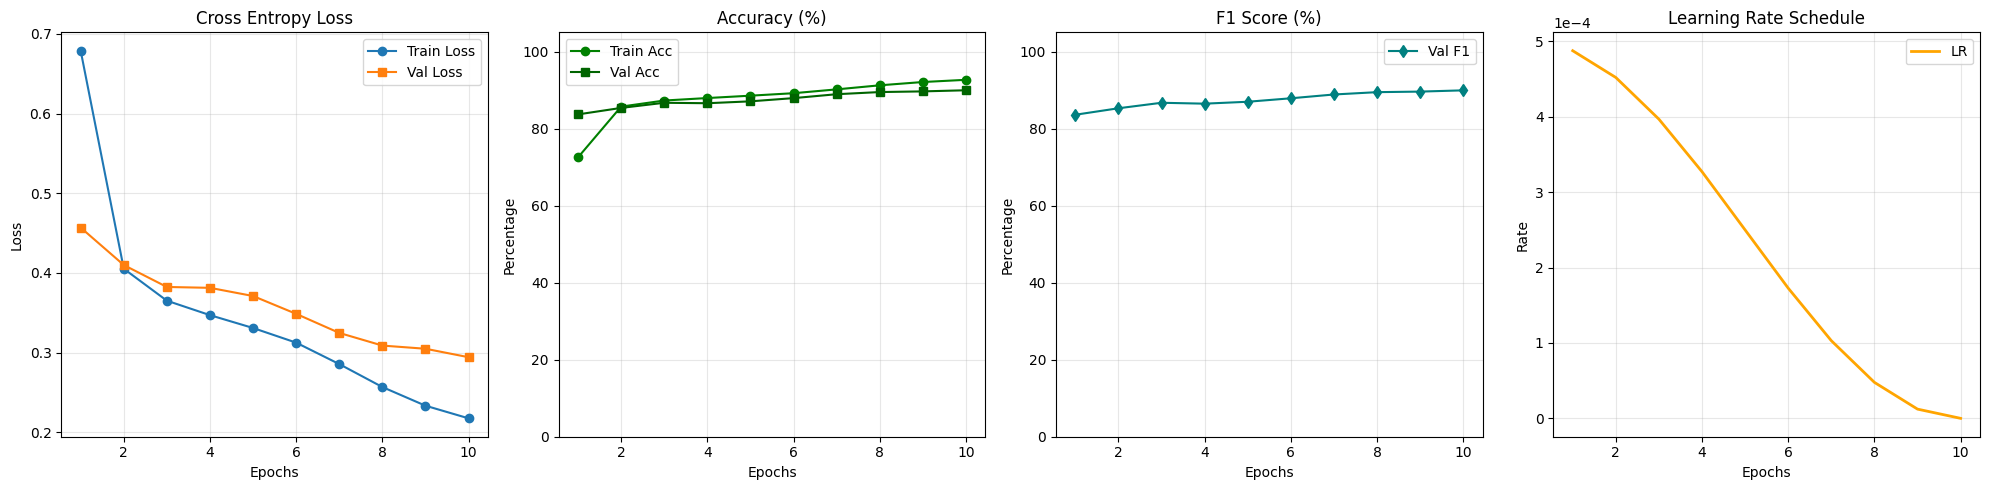

In [18]:
# Visualize & Audit
plot_history(history)


             FINAL TEST SET AUDIT              
Loss: 0.2978 | Accuracy: 90.16% | F1: 0.9015

Classification Report:
               precision    recall  f1-score   support

       World       0.93      0.89      0.91      1900
      Sports       0.94      0.96      0.95      1900
    Business       0.88      0.86      0.87      1900
    Sci/Tech       0.87      0.89      0.88      1900

    accuracy                           0.90      7600
   macro avg       0.90      0.90      0.90      7600
weighted avg       0.90      0.90      0.90      7600



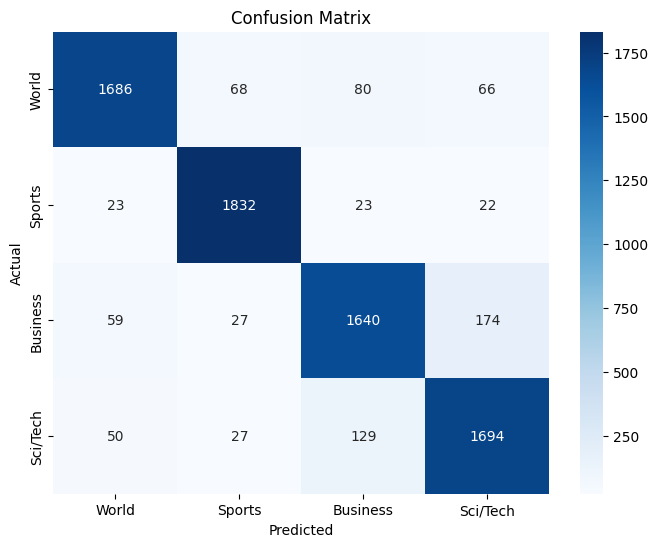


Final Summary | Loss: 0.2978 | Accuracy: 90.16% | F1-score: 90.15%


In [19]:
# --- Final Evaluation (The "Audit") ---
print("\n" + "="*50)
print("             FINAL TEST SET AUDIT              ")
print("="*50)

# We set plot=True here to get the Heatmap and Classification Report
test_loss, test_acc, test_f1 = evaluate_classification(
    model, 
    test_loader, 
    DEVICE, 
    is_binary=IS_BINARY, 
    class_names=class_names,
    plot=True
)

print("="*100)
print(f'\nFinal Summary | Loss: {test_loss:.4f} | Accuracy: {test_acc:.2%} | F1-score: {test_f1:.2%}')
print("="*100)

---
## 4. Model Inference and Sentiment Prediction

---

In [20]:
tokenizer

<function __main__.<lambda>(text)>

In [21]:
def predict_robust(model, sentence, vocab, tokenizer, class_names, is_binary=False):
    model.eval()

    # Step A: Tokenize exactly like training
    tokens = tokenizer(sentence)
    
    # Step B: Numericalize (Default to <UNK> index 1)
    indexed = [vocab.get(t, 1) for t in tokens]
    
    # Safety: Handle empty or purely non-alphanumeric input
    if len(indexed) == 0:
        return "N/A", 0.0

    # Step C: Prepare Tensors [Batch Size 1, Seq_Len]
    tensor = torch.LongTensor(indexed).unsqueeze(0).to(DEVICE)
    length = torch.LongTensor([len(indexed)]).to(DEVICE)

    with torch.no_grad():
        logits = model(tensor, length)

        if is_binary:
            # --- BINARY MODE (IMDB) ---
            # Flattens [1, 1] to [1] and squashes to 0-1
            prob = torch.sigmoid(logits.view(-1)).item()
            prediction_idx = 1 if prob > 0.5 else 0
            # Confidence is distance from the 0.5 decision boundary
            confidence = prob if prediction_idx == 1 else 1 - prob
        else:
            # --- MULTI-CLASS MODE (AG News, etc.) ---
            # Converts logits to a probability distribution across N classes
            probs = torch.softmax(logits, dim=1)
            prediction_idx = torch.argmax(probs, dim=1).item()
            confidence = probs[0][prediction_idx].item()

    # Map the index back to the human-readable string from metadata
    label = class_names[prediction_idx]
    
    return label, confidence

# ================================================================================
def run_test_suite(model, tests, vocab, tokenizer, class_names, is_binary):
    """
    Runs a batch of tests and prints a professional, formatted report.
    """
    print(f"{'Input Sentence (First 50 chars)':<55} | {'Prediction':<12} | {'Conf'}")
    print("-" * 80)
    
    for text in tests:
        # Our universal prediction function
        label, conf = predict_robust(
            model, text, vocab, tokenizer, class_names, is_binary
        )
        
        # Simple threshold for "High Confidence" (e.g., 80%)
        # In a notebook, this makes identifying weaknesses easy
        marker = "★" if conf > 0.8 else " "
        
        print(f"{text[:50]:<55} | {label:<12} | {conf:>6.1%} {marker}")

In [22]:
# 1. Define the test cases
ag_news_tests = [
    "The Federal Reserve is expected to keep interest rates steady as inflation cools.",   # Business
    "The star striker scored a hat-trick in the final minutes of the world cup qualifier.",# Sports
    "Astronomers have discovered a new Earth-like planet orbiting a distant star system.",# Sci/Tech
    "Protests erupted in the capital city following the controversial election results.", # World
    "New software update fixes critical security vulnerabilities in mobile operating systems.", # Sci/Tech
    "Wall Street closes higher as tech stocks rally despite global trade tensions.",       # Business
    "NASA's rover successfully collected soil samples from the Martian surface.",          # Sci/Tech
    "The prime minister announced a new coalition government after weeks of deadlock.",    # World
    "The underdog team secured a historic victory in the grand slam final today.",         # Sports
    "A massive cyberattack has compromised thousands of corporate database records."       # Sci/Tech
]

# 2. Run the Robust Test Suite
print(f"{'Headline (First 58 chars)':<60} | {'Prediction':<12} | {'Confidence'}")
print("-" * 90)

for text in ag_news_tests:
    # Use the universal predict_robust function we built
    topic, conf = predict_robust(
        model, text, vocab, tokenizer, class_names, is_binary=IS_BINARY
    )
    
    # Visual confidence indicator (Pro touch)
    marker = "★" if conf > 0.85 else " "
    
    # Truncate text for a clean table view
    print(f"{text[:58]:<60} | {topic:<12} | {conf:>6.1%} {marker}")

Headline (First 58 chars)                                    | Prediction   | Confidence
------------------------------------------------------------------------------------------
The Federal Reserve is expected to keep interest rates ste   | Business     |  76.6%  
The star striker scored a hat-trick in the final minutes o   | Sports       |  98.1% ★
Astronomers have discovered a new Earth-like planet orbiti   | Sci/Tech     |  86.6% ★
Protests erupted in the capital city following the controv   | World        |  60.9%  
New software update fixes critical security vulnerabilitie   | Sci/Tech     |  95.0% ★
Wall Street closes higher as tech stocks rally despite glo   | Business     |  84.4%  
NASA's rover successfully collected soil samples from the    | Sci/Tech     |  91.3% ★
The prime minister announced a new coalition government af   | World        |  75.3%  
The underdog team secured a historic victory in the grand    | Sports       |  89.8% ★
A massive cyberattack has compromised

In [23]:
%watermark -iv

datasets   : 4.0.0
matplotlib : 3.10.0
numpy      : 2.0.2
pandas     : 2.3.3
re         : 2.2.1
seaborn    : 0.13.2
sklearn    : 1.6.1
torch      : 2.9.0+cu126
torchinfo  : 1.8.0
torchvision: 0.24.0+cu126

